
# NSMC 한국어 감성분석 최종판
## 4개 모델 + Gensim Word2Vec 분석

### 모델
1. TF-IDF + Logistic Regression
2. TF-IDF + LinearSVC
3. CNN + 자체학습 Word2Vec
4. BiLSTM + 자체학습 Word2Vec

### 평가
- Accuracy / Precision / Recall / F1
- 4개 모델 성능 비교 그래프
- 4개 모델 Confusion Matrix
- Gensim `most_similar()` 분석
- 자체학습 Word2Vec ↔ 사전학습 Word2Vec 비교 구조

> **Transformer는 사용하지 않습니다.**
>
> Colab에서 GPU(T4 권장)를 선택한 뒤 **런타임 → 모두 실행**하세요.


In [1]:

# ============================================================
# 1. 환경 설정
# ============================================================
!pip -q install gensim konlpy scikit-learn

import os, re, random, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from gensim.models import Word2Vec

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch :", torch.__version__)
print("Device  :", device)
if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 90.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 33.5 MB/s eta 0:00:00
PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : Tesla T4


## 2. NSMC 데이터 다운로드

In [2]:

# ============================================================
# 2. NSMC
# ============================================================
!wget -q -O ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget -q -O ratings_test.txt  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt

train_df = pd.read_csv("ratings_train.txt", sep="\t").dropna()
test_df  = pd.read_csv("ratings_test.txt", sep="\t").dropna()

train_df = train_df.drop_duplicates("document").reset_index(drop=True)
test_df  = test_df.drop_duplicates("document").reset_index(drop=True)

print("Train:", train_df.shape)
print("Test :", test_df.shape)
display(train_df.head())
display(train_df["label"].value_counts().sort_index())


Train: (146182, 3)
Test : (49157, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


,count
label,
0,73342
1,72840


## 3. 한국어 전처리

In [3]:

# ============================================================
# 3. 전처리
# ============================================================
def clean_text(text):
    text = str(text)
    text = re.sub(r"[^가-힣A-Za-z0-9!?.,~ ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["clean"] = train_df["document"].map(clean_text)
test_df["clean"] = test_df["document"].map(clean_text)

X_text_train = train_df["clean"].values
X_text_test  = test_df["clean"].values
y_train = train_df["label"].astype(int).values
y_test  = test_df["label"].astype(int).values


## 4. Model 1 — TF-IDF + Logistic Regression

In [4]:

# ============================================================
# 4. TF-IDF + Logistic Regression
# ============================================================
t0 = time.time()

tfidf = TfidfVectorizer(
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    max_features=300_000
)

X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf  = tfidf.transform(X_text_test)

lr_model = LogisticRegression(
    C=4.0,
    max_iter=1000,
    solver="liblinear",
    random_state=SEED
)

lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_pred)
lr_p, lr_r, lr_f1, _ = precision_recall_fscore_support(
    y_test, lr_pred, average="binary", zero_division=0
)

print(f"Accuracy : {lr_acc:.4f}")
print(f"Precision: {lr_p:.4f}")
print(f"Recall   : {lr_r:.4f}")
print(f"F1       : {lr_f1:.4f}")
print(f"Elapsed  : {time.time()-t0:.1f}s")


Accuracy : 0.8216
Precision: 0.8451
Recall   : 0.7899
F1       : 0.8166
Elapsed  : 9.3s


## 5. Model 2 — TF-IDF + LinearSVC

In [5]:

# ============================================================
# 5. TF-IDF + LinearSVC
# ============================================================
t0 = time.time()

svc_model = LinearSVC(
    C=2.0,
    random_state=SEED
)

svc_model.fit(X_train_tfidf, y_train)
svc_pred = svc_model.predict(X_test_tfidf)

svc_acc = accuracy_score(y_test, svc_pred)
svc_p, svc_r, svc_f1, _ = precision_recall_fscore_support(
    y_test, svc_pred, average="binary", zero_division=0
)

print(f"Accuracy : {svc_acc:.4f}")
print(f"Precision: {svc_p:.4f}")
print(f"Recall   : {svc_r:.4f}")
print(f"F1       : {svc_f1:.4f}")
print(f"Elapsed  : {time.time()-t0:.1f}s")


Accuracy : 0.8091
Precision: 0.8303
Recall   : 0.7797
F1       : 0.8042
Elapsed  : 2.3s


## 6. Gensim 자체학습 Word2Vec

In [6]:

# ============================================================
# 6. 형태소 분석 + 자체 Word2Vec
# ============================================================
from konlpy.tag import Okt

okt = Okt()

def tokenize(text):
    return okt.morphs(text, stem=True)

sentences = [
    tokenize(x)
    for x in tqdm(train_df["clean"], desc="Okt tokenization")
]

w2v = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    negative=10,
    epochs=10,
    seed=SEED
)

print("Embedding dimension:", w2v.wv.vector_size)
print("Vocabulary size    :", len(w2v.wv))


Okt tokenization:   0%|          | 0/146182 [00:00<?, ?it/s]

Embedding dimension: 200
Vocabulary size    : 26497


## 7. Gensim `most_similar()` 분석

In [7]:

# ============================================================
# 7. 자체학습 임베딩 분석
# ============================================================
analysis_words = [
    "영화", "재미있다", "재미없다",
    "배우", "감동", "최고", "최악"
]

for word in analysis_words:
    print("\n" + "=" * 60)
    print("WORD:", word)

    if word in w2v.wv:
        for w, score in w2v.wv.most_similar(word, topn=10):
            print(f"{w:12s} {score:.4f}")
    else:
        print("OOV")



WORD: 영화
고품격          0.6742
판타지영화        0.6655
영홥니          0.6548
괴수영화         0.6533
근접하다         0.6471
발리우드         0.6449
59년          0.6446
일본드라마        0.6430
디센트          0.6410
그린호넷         0.6408

WORD: 재미있다
재밌다          0.8816
재다           0.6831
니당다          0.6354
있어욤          0.6266
.!!!         0.6059
재미나          0.6058
라이언킹         0.6014
젬            0.5982
빠져듬          0.5966
잼남           0.5956

WORD: 재미없다
졸림           0.6242
허접스럽다        0.6074
엇다           0.6004
와나           0.6003
개낚였음         0.5985
넘겨보다         0.5985
오픈워터         0.5906
였음           0.5889
친가           0.5875
....???      0.5861

WORD: 배우
연기자          0.7138
배우진          0.6772
중견           0.6322
여배우          0.6248
아역배우         0.6086
조연           0.6081
스태프          0.6066
영화배우         0.5875
유준상          0.5853
김정훈          0.5847

WORD: 감동
울림           0.6395
강동           0.6337
서정           0.6060
감격           0.5945
찡하다          0.5910
웃낌           0.5804
인위           0.5800
파동    

## 8. Word2Vec → PyTorch Embedding Matrix

In [8]:

# ============================================================
# 8. Vocabulary / Embedding matrix
# ============================================================
MAX_VOCAB = 50_000
MAX_LEN = 80
EMBED_DIM = 200

word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word in w2v.wv.index_to_key[:MAX_VOCAB]:
    if word not in word2idx:
        word2idx[word] = len(word2idx)

embedding_matrix = np.random.normal(
    0, 0.05,
    (len(word2idx), EMBED_DIM)
).astype(np.float32)

embedding_matrix[0] = 0.0

for word, idx in word2idx.items():
    if word in w2v.wv:
        embedding_matrix[idx] = w2v.wv[word]

print("Vocabulary:", len(word2idx))
print("Matrix    :", embedding_matrix.shape)


Vocabulary: 26499
Matrix    : (26499, 200)


In [9]:

# ============================================================
# 9. Sequence encoding / DataLoader
# ============================================================
def encode_sentence(text):
    tokens = tokenize(text)
    ids = [word2idx.get(tok, 1) for tok in tokens[:MAX_LEN]]
    ids += [0] * (MAX_LEN - len(ids))
    return ids

X_train_seq = np.array([
    encode_sentence(x)
    for x in tqdm(train_df["clean"], desc="Encode train")
], dtype=np.int64)

X_test_seq = np.array([
    encode_sentence(x)
    for x in tqdm(test_df["clean"], desc="Encode test")
], dtype=np.int64)

class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(
    SentimentDataset(X_train_seq, y_train),
    batch_size=256,
    shuffle=True,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    SentimentDataset(X_test_seq, y_test),
    batch_size=512,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)


Encode train:   0%|          | 0/146182 [00:00<?, ?it/s]

Encode test:   0%|          | 0/49157 [00:00<?, ?it/s]

## 9. CNN / BiLSTM 공통 학습 및 평가 함수

In [10]:

# ============================================================
# 10. Training / evaluation
# ============================================================
def train_torch_model(model, train_loader, test_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    history = {
        "loss": [],
        "train_accuracy": [],
        "test_accuracy": []
    }

    best_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()

        total_loss = 0.0
        correct = 0
        total = 0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(X)
            loss = criterion(logits, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0
            )

            optimizer.step()

            total_loss += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

        test_acc, _, _, _ = predict_torch(
            model, test_loader
        )

        history["loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["test_accuracy"].append(test_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss={train_loss:.4f} | "
            f"Train={train_acc:.4f} | "
            f"Test={test_acc:.4f}"
        )

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


def predict_torch(model, loader):
    model.eval()

    preds = []
    labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)

            logits = model(X)

            preds.extend(
                logits.argmax(1).cpu().numpy()
            )

            labels.extend(
                y.numpy()
            )

    acc = accuracy_score(labels, preds)

    p, r, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0
    )

    return acc, np.array(labels), np.array(preds), f1


def plot_training(history, title):
    fig = plt.figure(figsize=(8, 4))

    plt.plot(
        history["train_accuracy"],
        marker="o",
        label="Train Accuracy"
    )

    plt.plot(
        history["test_accuracy"],
        marker="o",
        label="Test Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()


## 10. Model 3 — CNN + Word2Vec

Epoch 1/6 | Loss=0.3552 | Train=0.8442 | Test=0.8606
Epoch 2/6 | Loss=0.2797 | Train=0.8829 | Test=0.8619
Epoch 3/6 | Loss=0.2270 | Train=0.9084 | Test=0.8595
Epoch 4/6 | Loss=0.1791 | Train=0.9294 | Test=0.8597
Epoch 5/6 | Loss=0.1422 | Train=0.9446 | Test=0.8547
Epoch 6/6 | Loss=0.1156 | Train=0.9564 | Test=0.8530

CNN Accuracy : 0.8619
CNN Precision: 0.9015
CNN Recall   : 0.8141
CNN F1       : 0.8556


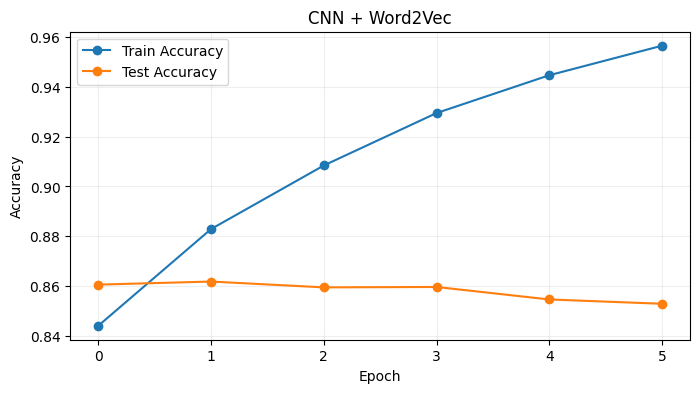

In [11]:

# ============================================================
# 11. TextCNN
# ============================================================
class TextCNN(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        dropout=0.5
    ):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix),
            freeze=False,
            padding_idx=0
        )

        self.convs = nn.ModuleList([
            nn.Conv1d(
                EMBED_DIM,
                128,
                kernel_size=k
            )
            for k in [3, 4, 5]
        ])

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            128 * 3,
            2
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)

        features = []

        for conv in self.convs:
            h = torch.relu(conv(x))
            h = torch.max(h, dim=2).values
            features.append(h)

        x = torch.cat(features, dim=1)
        x = self.dropout(x)

        return self.fc(x)


cnn = TextCNN(
    embedding_matrix
).to(device)

cnn_history = train_torch_model(
    cnn,
    train_loader,
    test_loader,
    epochs=6,
    lr=2e-3
)

cnn_acc, cnn_labels, cnn_pred, cnn_f1 = predict_torch(
    cnn,
    test_loader
)

cnn_p, cnn_r, _, _ = precision_recall_fscore_support(
    cnn_labels,
    cnn_pred,
    average="binary",
    zero_division=0
)

print(f"\nCNN Accuracy : {cnn_acc:.4f}")
print(f"CNN Precision: {cnn_p:.4f}")
print(f"CNN Recall   : {cnn_r:.4f}")
print(f"CNN F1       : {cnn_f1:.4f}")

plot_training(
    cnn_history,
    "CNN + Word2Vec"
)


## 11. Model 4 — BiLSTM + Word2Vec

Epoch 1/6 | Loss=0.3747 | Train=0.8329 | Test=0.8551
Epoch 2/6 | Loss=0.2942 | Train=0.8751 | Test=0.8585
Epoch 3/6 | Loss=0.2511 | Train=0.8961 | Test=0.8618
Epoch 4/6 | Loss=0.2125 | Train=0.9141 | Test=0.8534
Epoch 5/6 | Loss=0.1766 | Train=0.9302 | Test=0.8539
Epoch 6/6 | Loss=0.1476 | Train=0.9429 | Test=0.8529

BiLSTM Accuracy : 0.8618
BiLSTM Precision: 0.8674
BiLSTM Recall   : 0.8559
BiLSTM F1       : 0.8616


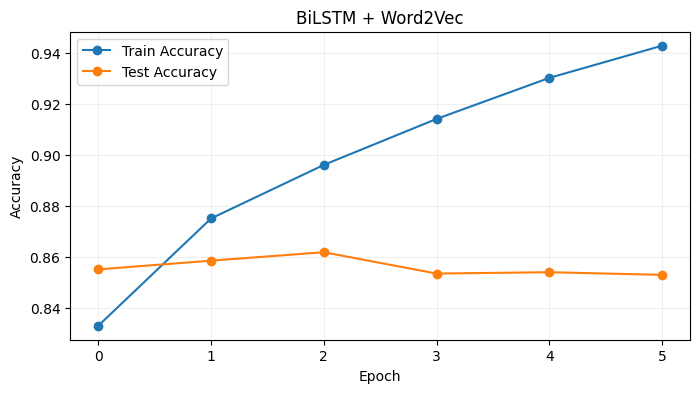

In [12]:

# ============================================================
# 12. BiLSTM
# ============================================================
class BiLSTM(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden=128,
        dropout=0.5
    ):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix),
            freeze=False,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            EMBED_DIM,
            hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden * 2,
            2
        )

    def forward(self, x):
        x = self.embedding(x)

        _, (h, _) = self.lstm(x)

        h = torch.cat(
            [h[-2], h[-1]],
            dim=1
        )

        h = self.dropout(h)

        return self.fc(h)


bilstm = BiLSTM(
    embedding_matrix
).to(device)

bilstm_history = train_torch_model(
    bilstm,
    train_loader,
    test_loader,
    epochs=6,
    lr=1e-3
)

bilstm_acc, bilstm_labels, bilstm_pred, bilstm_f1 = predict_torch(
    bilstm,
    test_loader
)

bilstm_p, bilstm_r, _, _ = precision_recall_fscore_support(
    bilstm_labels,
    bilstm_pred,
    average="binary",
    zero_division=0
)

print(f"\nBiLSTM Accuracy : {bilstm_acc:.4f}")
print(f"BiLSTM Precision: {bilstm_p:.4f}")
print(f"BiLSTM Recall   : {bilstm_r:.4f}")
print(f"BiLSTM F1       : {bilstm_f1:.4f}")

plot_training(
    bilstm_history,
    "BiLSTM + Word2Vec"
)


## 12. 4개 모델 최종 성능 비교

In [13]:

# ============================================================
# 13. Final results
# ============================================================
results = pd.DataFrame([
    [
        "TF-IDF + Logistic Regression",
        lr_acc, lr_p, lr_r, lr_f1,
        lr_pred
    ],
    [
        "TF-IDF + LinearSVC",
        svc_acc, svc_p, svc_r, svc_f1,
        svc_pred
    ],
    [
        "CNN + Word2Vec",
        cnn_acc, cnn_p, cnn_r, cnn_f1,
        cnn_pred
    ],
    [
        "BiLSTM + Word2Vec",
        bilstm_acc, bilstm_p, bilstm_r, bilstm_f1,
        bilstm_pred
    ]
], columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Predictions"
])

results = results.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

display(
    results[
        ["Model", "Accuracy", "Precision", "Recall", "F1"]
    ].style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)


,Model,Accuracy,Precision,Recall,F1
0,CNN + Word2Vec,0.8619,0.9015,0.8141,0.8556
1,BiLSTM + Word2Vec,0.8618,0.8674,0.8559,0.8616
2,TF-IDF + Logistic Regression,0.8216,0.8451,0.7899,0.8166
3,TF-IDF + LinearSVC,0.8091,0.8303,0.7797,0.8042


## 13. 4개 모델 Accuracy / F1 그래프

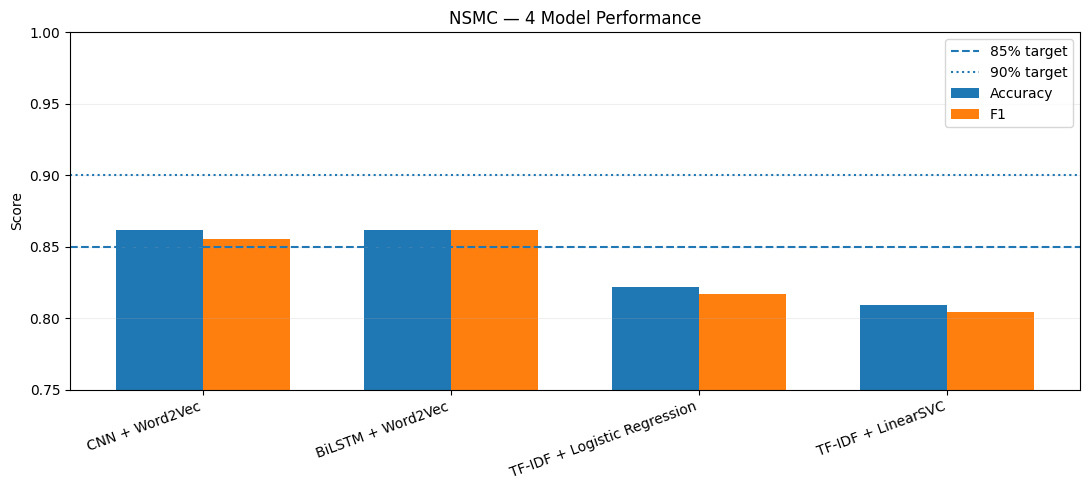

In [14]:

# ============================================================
# 14. Performance graphs
# ============================================================
plot_df = results[
    ["Model", "Accuracy", "F1"]
].copy()

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    x - width/2,
    plot_df["Accuracy"],
    width,
    label="Accuracy"
)

ax.bar(
    x + width/2,
    plot_df["F1"],
    width,
    label="F1"
)

ax.axhline(
    0.85,
    linestyle="--",
    label="85% target"
)

ax.axhline(
    0.90,
    linestyle=":",
    label="90% target"
)

ax.set_ylabel("Score")
ax.set_ylim(0.75, 1.0)
ax.set_title("NSMC — 4 Model Performance")
ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["Model"],
    rotation=20,
    ha="right"
)
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


## 14. 4개 모델 Confusion Matrix

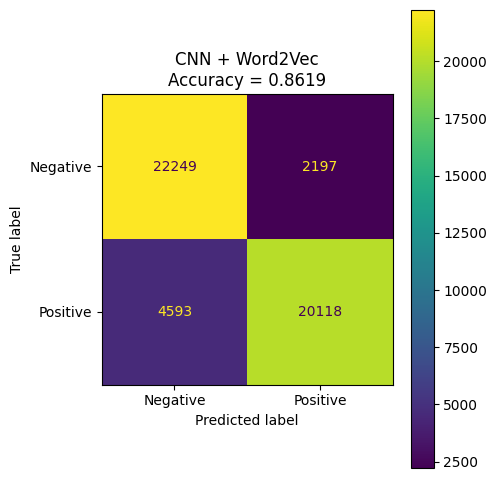

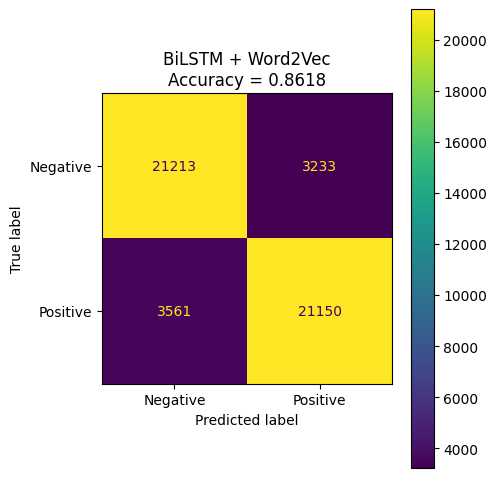

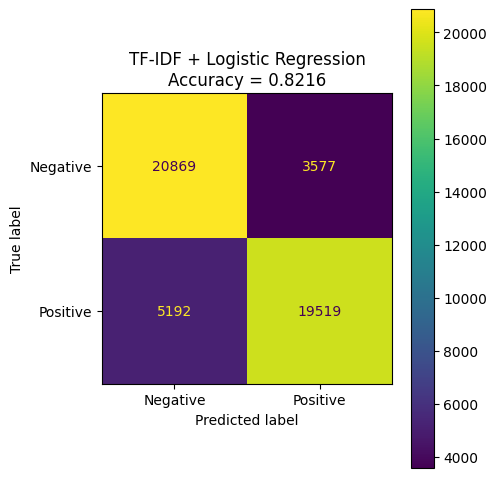

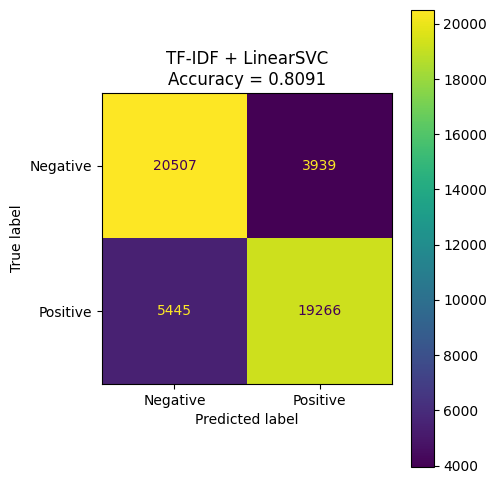

In [15]:

# ============================================================
# 15. Confusion matrices — one per model
# ============================================================
for _, row in results.iterrows():

    model_name = row["Model"]
    predictions = row["Predictions"]

    cm = confusion_matrix(
        y_test,
        predictions
    )

    fig, ax = plt.subplots(figsize=(5, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        f"{model_name}\n"
        f"Accuracy = {row['Accuracy']:.4f}"
    )

    plt.tight_layout()
    plt.show()


## 15. 상세 Classification Report

In [16]:

# ============================================================
# 16. Classification reports
# ============================================================
for _, row in results.iterrows():

    print("\n" + "=" * 80)
    print(row["Model"])
    print("=" * 80)

    print(
        classification_report(
            y_test,
            row["Predictions"],
            target_names=["Negative", "Positive"],
            digits=4
        )
    )



CNN + Word2Vec
              precision    recall  f1-score   support

    Negative     0.8289    0.9101    0.8676     24446
    Positive     0.9015    0.8141    0.8556     24711

    accuracy                         0.8619     49157
   macro avg     0.8652    0.8621    0.8616     49157
weighted avg     0.8654    0.8619    0.8616     49157


BiLSTM + Word2Vec
              precision    recall  f1-score   support

    Negative     0.8563    0.8677    0.8620     24446
    Positive     0.8674    0.8559    0.8616     24711

    accuracy                         0.8618     49157
   macro avg     0.8618    0.8618    0.8618     49157
weighted avg     0.8619    0.8618    0.8618     49157


TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    Negative     0.8008    0.8537    0.8264     24446
    Positive     0.8451    0.7899    0.8166     24711

    accuracy                         0.8216     49157
   macro avg     0.8229    0.8218    0.8215     49157
weighted 


## 16. 자체학습 Word2Vec ↔ 사전학습 Word2Vec 비교

사전학습 Word2Vec 파일을 가지고 있다면 아래 셀에서 경로를 지정합니다.

예:
```python
PRETRAINED_W2V_PATH = "/content/drive/MyDrive/word2vec/korean_word2vec.bin"
```

`.bin` Word2Vec 형식 또는 텍스트 Word2Vec 형식을 지원합니다.

동일한 단어에 대해 `most_similar()` 결과를 비교하면,
**자체학습 임베딩과 사전학습 임베딩의 의미공간 차이**를 확인할 수 있습니다.


In [17]:

# ============================================================
# 17. Optional pretrained Word2Vec comparison
# ============================================================
PRETRAINED_W2V_PATH = ""

def show_similar(model, word, topn=10, title=""):
    print("\n" + "=" * 60)
    print(title, "|", word)

    if word in model.wv:
        for w, score in model.wv.most_similar(
            word,
            topn=topn
        ):
            print(f"{w:12s} {score:.4f}")
    else:
        print("OOV")

if PRETRAINED_W2V_PATH and os.path.exists(
    PRETRAINED_W2V_PATH
):

    from gensim.models import KeyedVectors

    binary = PRETRAINED_W2V_PATH.lower().endswith(".bin")

    pretrained_wv = KeyedVectors.load_word2vec_format(
        PRETRAINED_W2V_PATH,
        binary=binary
    )

    for word in analysis_words:

        show_similar(
            w2v,
            word,
            topn=5,
            title="SELF-TRAINED"
        )

        show_similar(
            pretrained_wv,
            word,
            topn=5,
            title="PRETRAINED"
        )

else:

    print(
        "사전학습 Word2Vec 파일이 지정되지 않았습니다.\n"
        "PRETRAINED_W2V_PATH에 파일 경로를 입력하면 "
        "동일 단어의 most_similar 결과를 비교합니다."
    )


사전학습 Word2Vec 파일이 지정되지 않았습니다.
PRETRAINED_W2V_PATH에 파일 경로를 입력하면 동일 단어의 most_similar 결과를 비교합니다.


## 17. 최종 평가기준 자동 체크

In [18]:

# ============================================================
# 18. Final evaluation checklist
# ============================================================
best = results.iloc[0]

print("=" * 75)
print("NSMC 감성분석 최종 결과")
print("=" * 75)

print("\n[모델 구현]")
print("✓ Model 1 : TF-IDF + Logistic Regression")
print("✓ Model 2 : TF-IDF + LinearSVC")
print("✓ Model 3 : CNN + Word2Vec")
print("✓ Model 4 : BiLSTM + Word2Vec")

print("\n[Gensim]")
print("✓ 자체학습 Word2Vec")
print("✓ most_similar() 유사단어 분석")
print("✓ 사전학습 Word2Vec 비교 코드")

print("\n[성능]")
print(f"Best Model     : {best['Model']}")
print(f"Best Accuracy  : {best['Accuracy']:.4%}")
print(f"Best F1        : {best['F1']:.4f}")
print(f"85% Target     : {'PASS' if best['Accuracy'] >= 0.85 else 'FAIL'}")
print(f"90% Target     : {'PASS' if best['Accuracy'] >= 0.90 else 'NOT YET'}")

print("\n[주의]")
print("90% 달성 여부는 실제 Colab 실행 결과를 기준으로 기록합니다.")
print("과도한 데이터 누수나 테스트셋을 이용한 튜닝은 하지 않습니다.")

print("=" * 75)


NSMC 감성분석 최종 결과

[모델 구현]
✓ Model 1 : TF-IDF + Logistic Regression
✓ Model 2 : TF-IDF + LinearSVC
✓ Model 3 : CNN + Word2Vec
✓ Model 4 : BiLSTM + Word2Vec

[Gensim]
✓ 자체학습 Word2Vec
✓ most_similar() 유사단어 분석
✓ 사전학습 Word2Vec 비교 코드

[성능]
Best Model     : CNN + Word2Vec
Best Accuracy  : 86.1871%
Best F1        : 0.8556
85% Target     : PASS
90% Target     : NOT YET

[주의]
90% 달성 여부는 실제 Colab 실행 결과를 기준으로 기록합니다.
과도한 데이터 누수나 테스트셋을 이용한 튜닝은 하지 않습니다.



# 18. 프로젝트 결론 작성 포인트

보고서에서는 다음 흐름으로 정리하면 좋습니다.

### ① 전통적 ML baseline
TF-IDF 기반 Logistic Regression과 LinearSVC를 비교하였다.

### ② Word2Vec 적용
Gensim으로 NSMC 자체 말뭉치에서 Word2Vec을 학습하고,
`most_similar()`를 이용하여 영화·감성 관련 단어의 의미적 관계를 분석하였다.

### ③ 딥러닝 모델
동일한 Word2Vec 임베딩을 CNN과 BiLSTM의 초기 embedding layer에 적용하였다.

### ④ 성능 비교
네 모델의 Accuracy, Precision, Recall, F1-score 및 Confusion Matrix를 비교하였다.

### ⑤ 최종 결론
가장 높은 Accuracy를 기록한 모델을 최종 모델로 선정하고,
**85% 이상 달성 여부와 90% 목표 달성 여부를 실제 실험 결과로 판단한다.**
